# Handbrake turn

Step 11.1. From the start mark: straight at full throttle, full lock, and at a heading from the gyro
speed 0. At duty 0 the BTS7960 shorts the motor: the rear wheels lock in 0.35-0.4 s and the car
slides. `scripts/handbrake.py` in open loop; `handbrake_node` steers the slide to a heading.

Runs of 2026-09-29 on the tiles: bags `data/bags/hb_*`, overhead video `data/video/hb_*.mkv` from
the phone stream. The stream arrives in bursts: positions and angles are good, its timestamps are
not (speeds come from frames retimed by the gyro heading, below).

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import videotools as vt
import vehicle_model as vm

plt.rcParams['figure.dpi'] = 72
B = '../data/bags'
K_REAR = vt.PINK_BEHIND / vt.D_MARK
LOCK = np.interp(0.52, vm.CMD, vm.DEL)


def bag(run):
    # commands, wheel speed, gyro heading from the first command (bias from the rest before it)
    d = pd.read_parquet(f'{B}/{run}_parquet/drive.parquet')
    j = pd.read_parquet(f'{B}/{run}_parquet/joint_states.parquet')
    im = pd.read_parquet(f'{B}/{run}_parquet/imu_data_raw.parquet')
    t_go = d.loc[d['cmd_speed'] > 0.05, 't'].iloc[0]
    t_brake = d.loc[(d['t'] > t_go + 0.5) & (d['cmd_speed'] < 0.02), 't'].iloc[0]
    t = im['t'].to_numpy()
    r = im['gz'].to_numpy() - im.loc[im['t'] < t_go - 0.2, 'gz'].median()
    heading = np.concatenate([[0], np.cumsum(np.diff(t) * r[1:])])
    heading -= np.interp(t_go, t, heading)
    wheels = (j['wl'] + j['wr']).to_numpy() / 2 * vm.p['wheel_radius']
    return dict(d=d, t_go=t_go, t_brake=t_brake, t=t, r=r, heading=heading, t_wheels=j['t'].to_numpy(), wheels=wheels)


def video(run):
    # rear axle and heading from the markers, in the frame of the car at the start (x ahead, y left)
    v = vt.load_track(f'../data/video/{run}_markers.parquet')
    v = v[v['valid']]
    pink = v[['pink_x', 'pink_y']].to_numpy(float)
    green = v[['green_x', 'green_y']].to_numpy(float)
    rear = pink + K_REAR * (green - pink)
    psi = np.unwrap(v['psi'].to_numpy())
    psi0 = np.median(psi[:25])
    d = (rear - np.median(rear[:25], axis=0)) * v['scale'].to_numpy()[:, None] * [1, -1]    # image y points down
    x = d[:, 0] * np.cos(psi0) + d[:, 1] * np.sin(psi0)
    y = -d[:, 0] * np.sin(psi0) + d[:, 1] * np.cos(psi0)
    return x, y, psi - psi0

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Open loop

`handbrake.py <speed> <straight> <brake_at> [steer] [steer braked]`: 1 s ramp to 1.5 m/s (above
what the motor reaches), `straight` s, full lock until the gyro heading reaches `brake_at`, then
speed 0 for 1 s. First three runs between two boxes (`hb_park1`-`3`, the box corners measured by
the lidar from the start), then the straight and the brake heading changed (`hb_sw1`-`5`, `hb_sw5`
as the park runs), then the steering in the slide (`hb_st`: straight, `hb_cs`: countersteer).

In [2]:
RUNS = {    # straight [s], brake at [deg], steering command in the slide
    'hb_park1': (0.5, 136, 0.52), 'hb_park2': (0.5, 136, 0.52), 'hb_park3': (0.5, 136, 0.52),
    'hb_sw1': (0.25, 136, 0.52), 'hb_sw2': (0.75, 136, 0.52), 'hb_sw3': (0.5, 110, 0.52),
    'hb_sw4': (0.5, 160, 0.52), 'hb_sw5': (0.5, 136, 0.52),
    'hb_st1': (0.5, 136, 0.0), 'hb_st2': (0.5, 136, 0.0), 'hb_cs1': (0.5, 136, -0.52), 'hb_cs2': (0.5, 136, -0.52)}
rows = []
for run, (straight, brake_at, steer) in RUNS.items():
    b = bag(run)
    x, y, psi = video(run)
    h_brake = np.interp(b['t_brake'], b['t'], b['heading'])
    rows.append({'run': run, 'straight [s]': straight, 'brake at [deg]': brake_at, 'steering in the slide': steer,
                 'wheels at the brake [m/s]': np.interp(b['t_brake'], b['t_wheels'], b['wheels']),
                 'r at the brake [rad/s]': np.interp(b['t_brake'], b['t'], b['r']),
                 'braked at [deg]': np.degrees(h_brake), 'slide [deg]': np.degrees(b['heading'][-1] - h_brake),
                 'stop, gyro [deg]': np.degrees(b['heading'][-1]), 'stop, video [deg]': np.degrees(np.median(psi[-25:])) % 360,
                 'stop x [m]': np.median(x[-25:]), 'stop y [m]': np.median(y[-25:])})
runs = pd.DataFrame(rows).set_index('run')
runs.round(2)

,straight [s],brake at [deg],steering in the slide,wheels at the brake [m/s],r at the brake [rad/s],braked at [deg],slide [deg],"stop, gyro [deg]","stop, video [deg]",stop x [m],stop y [m]
run,,,,,,,,,,,
hb_park1,0.50,136,0.52,1.02,1.72,138.32,42.11,180.43,179.99,1.37,0.81
hb_park2,0.50,136,0.52,0.99,1.91,136.59,40.61,177.20,179.17,1.41,0.80
hb_park3,0.50,136,0.52,0.99,1.64,138.67,42.94,181.61,183.32,1.39,0.81
hb_sw1,0.25,136,0.52,1.15,3.00,142.88,53.67,196.55,197.12,1.19,0.87
hb_sw2,0.75,136,0.52,1.14,2.15,138.88,55.96,194.84,196.41,1.70,0.99
hb_sw3,0.50,110,0.52,1.01,1.78,115.07,52.26,167.33,167.04,1.58,0.79
hb_sw4,0.50,160,0.52,1.12,2.63,165.22,53.66,218.88,221.50,1.22,0.77
hb_sw5,0.50,136,0.52,1.16,2.30,140.57,54.48,195.05,197.68,1.43,0.83
hb_st1,0.50,136,0.00,1.13,1.98,139.16,28.43,167.59,167.31,1.31,0.90


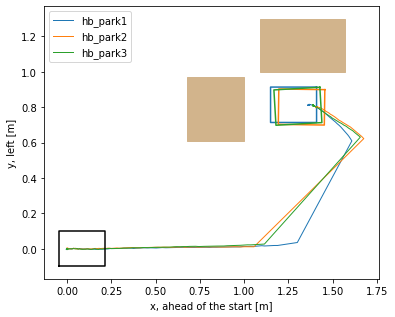

In [3]:
# the park runs and the boxes, from above; car outline at the stop
BOXES = [(0.68, 1.00, 0.61, 0.97), (1.09, 1.57, 1.00, 1.30)]
BODY = np.array([[-0.0435, -0.10], [0.2165, -0.10], [0.2165, 0.10], [-0.0435, 0.10], [-0.0435, -0.10]])
fig, ax = plt.subplots(figsize=(6, 6))
for x0, x1, y0, y1 in BOXES:
    ax.fill([x0, x1, x1, x0], [y0, y0, y1, y1], color='tan')
for i, run in enumerate(['hb_park1', 'hb_park2', 'hb_park3']):
    x, y, psi = video(run)
    ax.plot(x, y, f'C{i}', lw=1, label=run)
    c, s = np.cos(np.median(psi[-25:])), np.sin(np.median(psi[-25:]))
    ax.plot(np.median(x[-25:]) + BODY[:, 0] * c - BODY[:, 1] * s, np.median(y[-25:]) + BODY[:, 0] * s + BODY[:, 1] * c, f'C{i}')
ax.plot(BODY[:, 0], BODY[:, 1], 'k')
ax.set(xlabel='x, ahead of the start [m]', ylabel='y, left [m]', aspect='equal')
ax.legend()
plt.show()

### Result

Between the boxes three runs out of three, no contact: the rear axle stops 1.37-1.41 m ahead and
0.80-0.81 m left of the start, at 177-182 deg. The straight moves the stop ahead, ~0.2 m per 0.25 s;
the brake heading moves the final heading one to one.

But the slide after the brake is 41-43 deg in the park runs and 52-56 in the others with the same
commands (`hb_sw5`: 195 deg). At full lock and full throttle the wheels (1.0-1.16 m/s) and the yaw
rate (1.6-2.8 rad/s) swing a few times a second as the rear lets go and grips; the park runs braked
with the wheels at 0.99-1.02 m/s, the others at 1.11-1.16. The steering in the slide changes it:
19-28 deg with the wheels straight, 6-15 countersteered.

## The state at the brake

The heading from the video against the gyro heading gives each frame its time while the car turns
(the heading only grows); from those times the velocity of the rear axle in the 0.25 s before the
brake. Only the park and sweep runs have enough frames there (motion blur in the others).

In [4]:
def state_at_brake(run):
    # rear axle velocity in the car frame at the brake, from the video frames retimed by the gyro heading
    b = bag(run)
    x, y, psi = video(run)
    after = b['t'] > b['t_go']
    grown = np.maximum.accumulate(b['heading'][after])
    turning = (psi > np.radians(20)) & (psi < grown[-1] - np.radians(4))
    t = np.interp(psi[turning], grown, b['t'][after])
    w = (t > b['t_brake'] - 0.25) & (t < b['t_brake'] + 0.02)
    vx_w = np.polyfit(t[w], x[turning][w], 1)[0]
    vy_w = np.polyfit(t[w], y[turning][w], 1)[0]
    h = np.interp(b['t_brake'], b['t'], b['heading'])
    return np.cos(h) * vx_w + np.sin(h) * vy_w, -np.sin(h) * vx_w + np.cos(h) * vy_w


STATE_RUNS = ['hb_park1', 'hb_park2', 'hb_park3', 'hb_sw1', 'hb_sw4', 'hb_sw5']
brake = pd.DataFrame([dict(zip(['vx [m/s]', 'vy [m/s]'], state_at_brake(run)), run=run) for run in STATE_RUNS]).set_index('run')
brake['rear slip [deg]'] = np.degrees(np.arctan2(brake['vy [m/s]'], brake['vx [m/s]']))
brake = brake.join(runs[['r at the brake [rad/s]', 'wheels at the brake [m/s]', 'slide [deg]']])
brake.round(2)

,vx [m/s],vy [m/s],rear slip [deg],r at the brake [rad/s],wheels at the brake [m/s],slide [deg]
run,,,,,,
hb_park1,0.82,-0.13,-8.70,1.72,1.02,42.11
hb_park2,0.99,0.05,2.67,1.91,0.99,40.61
hb_park3,0.87,0.06,3.63,1.64,0.99,42.94
hb_sw1,0.82,-0.33,-21.58,3.00,1.15,53.67
hb_sw4,0.71,-0.33,-25.21,2.63,1.12,53.66
hb_sw5,0.73,-0.21,-15.62,2.30,1.16,54.48


### Result

The park runs braked with the car gripping (rear slip -9 to +4 deg), the others with the tail out
(-16 to -25 deg) and a higher yaw rate: those slide 10-15 deg more.

## The model of the slide

The Phase 5 model from the state at the brake, with the measured wheel speed (it falls to 0 in
0.35-0.4 s) and the steering commanded, compared on the yaw rate for 1 s from the brake. The locked
rear with the friction of the Phase 5 tire (`rear` 1.0) and scaled.

In [5]:
def deriv(x, u, d_cmd, rear):
    fx, fy, mz = vm.forces(x, u, rear=rear)
    return np.array([fx / vm.M + x[1] * x[2], fy / vm.M - x[0] * x[2], mz / vm.IZ, (d_cmd - x[3]) / vm.TAU])


def stopped(x, u):
    return x[0] < 0.06 and abs(x[1]) < 0.03 and u < 0.02


def slide(run, rear, steer=None, state=None, h=0.001):
    # yaw rate of the model for 1 s from the brake; the steering commanded or `steer` held, the rear axle
    # velocity at the brake from the video or `state`
    b = bag(run)
    vx, vy_rear = state_at_brake(run) if state is None else state
    r = np.interp(b['t_brake'], b['t'], b['r'])
    x = np.array([vx, vy_rear + vm.LR * r, r, LOCK])    # at full lock for over 1 s
    t = b['t_brake'] + np.arange(0, 1.0, h)
    cmd = np.interp(t, b['d']['t'], b['d']['cmd_steer']) if steer is None else np.full(len(t), steer)
    rs = np.zeros(len(t))
    for k in range(len(t)):
        u = np.interp(t[k], b['t_wheels'], b['wheels'])
        if stopped(x, u):
            break
        rs[k] = x[2]
        x = x + h * deriv(x, u, np.interp(cmd[k], vm.CMD, vm.DEL), rear)
    return t, rs


def yaw_rms(rear):
    errors = []
    for run in STATE_RUNS:
        b = bag(run)
        t, rs = slide(run, rear)
        errors.append(rs - np.interp(t, b['t'], b['r']))
    return np.sqrt(np.mean(np.concatenate(errors) ** 2))


pd.DataFrame({'rear': [1.0, 1.2, 1.4, 1.5, 1.6, 1.8],
              'yaw rate rms [rad/s]': [yaw_rms(k) for k in [1.0, 1.2, 1.4, 1.5, 1.6, 1.8]]}).round(3)

,rear,yaw rate rms [rad/s]
0,1.0,0.617
1,1.2,0.368
2,1.4,0.307
3,1.5,0.323
4,1.6,0.352
5,1.8,0.422


In [6]:
turned = lambda t, rs: np.degrees(np.sum(rs) * (t[1] - t[0]))
rows = []
for run in STATE_RUNS:
    rows.append({'run': run, 'measured, full lock': runs.loc[run, 'slide [deg]'],
                 'rear x1.0, full lock': turned(*slide(run, 1.0)), 'rear x1.5, full lock': turned(*slide(run, 1.5)),
                 'rear x1.5, straight': turned(*slide(run, 1.5, 0.0)), 'rear x1.5, countersteer': turned(*slide(run, 1.5, -0.52))})
pd.DataFrame(rows).set_index('run').round(0)

,"measured, full lock","rear x1.0, full lock","rear x1.5, full lock","rear x1.5, straight","rear x1.5, countersteer"
run,,,,,
hb_park1,42.0,63.0,41.0,21.0,0.0
hb_park2,41.0,89.0,53.0,26.0,-2.0
hb_park3,43.0,74.0,47.0,22.0,-2.0
hb_sw1,54.0,72.0,44.0,30.0,10.0
hb_sw4,54.0,61.0,39.0,26.0,10.0
hb_sw5,54.0,64.0,42.0,25.0,6.0


### Result

With the rear of the Phase 5 tire the model turns 7-48 deg too far after the brake. A locked rear
slides with more friction than a spinning one: x1.4 and x1.5 fit the yaw rate about as well (0.31
and 0.32 rad/s rms, 0.62 at x1.0), 0.39-0.41 of friction against 0.28. At x1.5 the model turns
about as far as the car at full lock (39-53 deg against 41-54) and with the wheels straight (21-30
against 19-28 in `hb_st`). It misses the difference between the gripping and the tail-out runs.
The node takes x1.5.

### Countersteered

`hb_cs` (full countersteer from the brake) and two runs of the node below that countersteered hard:
the heading after the brake from the gyro, and the model from the mean state at the brake (the video
has no frames there) with the steering commanded.

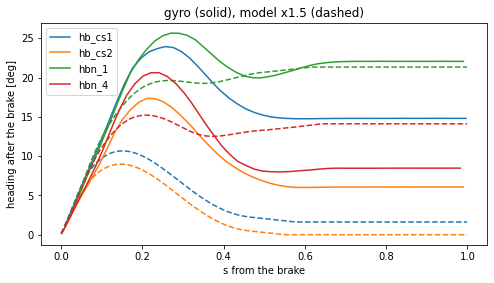

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, run in enumerate(['hb_cs1', 'hb_cs2', 'hbn_1', 'hbn_4']):
    b = bag(run)
    sel = (b['t'] >= b['t_brake']) & (b['t'] < b['t_brake'] + 1.0)
    h_brake = np.interp(b['t_brake'], b['t'], b['heading'])
    ax.plot(b['t'][sel] - b['t_brake'], np.degrees(b['heading'][sel] - h_brake), f'C{i}', label=run)
    t, rs = slide(run, 1.5, state=(0.82, -0.10))
    ax.plot(t - t[0], np.degrees(np.cumsum(rs) * (t[1] - t[0])), f'C{i}--')
ax.set(xlabel='s from the brake', ylabel='heading after the brake [deg]', title='gyro (solid), model x1.5 (dashed)')
ax.legend()
plt.show()

Countersteered, the car turns on to 17-25 deg after the brake, stops turning at the wheel lock
(~0.3 s) and swings back 5-12 deg. From the mean state at the brake the model turns less and swings
back less: in `hb_cs` up to 9-10 deg, 2 and 0 at the stop against 15 and 6; in `hbn_4` it swings
back 2.7 deg against 12.

## Steering to a heading

Every 20 ms: the model run to the stop with the steering held, from the state it carries, and
bisection on the steering for the one that stops at the target. Wheels braking as the motor driver
(`brake_lag`). The controller does not know vx and vy: it starts from the mean of the video
(0.82, -0.10 m/s at the rear axle) and carries them with the model; the yaw rate is the gyro's.
The car here is the model from the six measured brake states, its rear friction also off the
controller's 1.5; the target 35 deg after the brake. The predictive steering with the full range and
with the countersteer held to -0.15 (the swing back above).

In [8]:
LOCKED = 1.5
BRAKE_VX, BRAKE_VY = 0.82, -0.10


def final_heading(x, psi, u, steer, h=0.005):
    # where the car stops with the steering held
    d_cmd = np.interp(steer, vm.CMD, vm.DEL)
    for _ in range(int(1.5 / h)):
        if stopped(x, u):
            break
        x = x + h * deriv(x, u, d_cmd, LOCKED)
        psi += h * x[2]
        u *= np.exp(-h / vm.p['brake_lag'])
    return psi


def predictive(x, psi, u, target, lo=-0.52):
    hi = 0.52
    if final_heading(x, psi, u, lo) >= target:
        return lo
    if final_heading(x, psi, u, hi) <= target:
        return hi
    for _ in range(8):
        mid = (lo + hi) / 2
        if final_heading(x, psi, u, mid) < target:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2


CONTROLLERS = {
    'full lock': lambda x, psi, u, target: 0.52,
    'straight': lambda x, psi, u, target: 0.0,
    'PD': lambda x, psi, u, target: np.clip(4.0 * (target - psi) - 0.25 * x[2], -0.52, 0.52),
    'predictive': predictive,
    'predictive, to -0.15': lambda x, psi, u, target: predictive(x, psi, u, target, lo=-0.15),
}


def closed_loop(run, controller, rear_car, after=35.0):
    # final heading error [deg]: the car from its measured state at the brake, the measured wheel speed
    b = bag(run)
    vx, vy_rear = state_at_brake(run)
    r = np.interp(b['t_brake'], b['t'], b['r'])
    car = np.array([vx, vy_rear + vm.LR * r, r, LOCK])
    carried = np.array([BRAKE_VX, BRAKE_VY + vm.LR * r, r, LOCK])
    psi, steer, target, h = 0.0, 0.52, np.radians(after), 0.001
    for k in range(int(2.0 / h)):
        u = np.interp(b['t_brake'] + k * h, b['t_wheels'], b['wheels'])
        if stopped(car, u):
            break
        if k % 20 == 0:
            carried[2] = car[2]
            steer = CONTROLLERS[controller](carried, psi, u, target)
        d_cmd = np.interp(steer, vm.CMD, vm.DEL)
        car = car + h * deriv(car, u, d_cmd, rear_car)
        carried = carried + h * deriv(carried, u, d_cmd, LOCKED)
        carried[0] = max(carried[0], 0.0)
        psi += h * car[2]
    return np.degrees(psi - target)


rows = []
for controller in CONTROLLERS:
    for rear_car in [1.2, 1.5, 1.8]:
        errors = [closed_loop(run, controller, rear_car) for run in STATE_RUNS]
        rows.append({'controller': controller, 'rear of the car': rear_car, 'worst [deg]': np.abs(errors).max(),
                     **{run: e for run, e in zip(STATE_RUNS, errors)}})
pd.DataFrame(rows).round(1)

,controller,rear of the car,worst [deg],hb_park1,hb_park2,hb_park3,hb_sw1,hb_sw4,hb_sw5
0,full lock,1.2,34.1,16.1,34.1,24.1,22.1,14.3,17.2
1,full lock,1.5,17.5,6.0,17.5,11.9,9.2,4.2,7.1
2,full lock,1.8,7.9,-0.2,7.9,4.5,2.0,-1.5,1.3
3,straight,1.2,9.6,-9.6,-2.9,-9.2,5.3,-1.1,-4.4
4,straight,1.5,13.8,-13.8,-9.5,-12.9,-5.5,-8.7,-10.1
5,straight,1.8,16.2,-16.2,-13.0,-15.1,-10.8,-12.8,-13.0
6,PD,1.2,6.6,3.5,6.6,4.8,5.2,3.1,3.6
7,PD,1.5,3.7,0.4,3.7,2.3,1.6,-0.3,0.8
8,PD,1.8,3.1,-2.4,1.0,-0.3,-1.3,-3.1,-1.6
9,predictive,1.2,0.2,0.0,-0.2,-0.1,-0.0,0.0,-0.0


### Result

With the rear of the car as the controller's (x1.5) the predictive steering stops within 1.2 deg of
the target from all six brake states, with the full range or held to -0.15. With less rear friction
(x1.2) the car turns further than expected and only the countersteer holds it back: 0.2 deg with the
full range, 5.0 held to -0.15. With more (x1.8) both stop 4.3 deg short, at full lock. The PD 3-7 deg,
the wheels held straight up to 16, full lock up to 34.

## On the car

`handbrake_node` (C++, the functions above: 5 ms steps, 8 bisections, 20 ms on the Pi), first
version: the full steering range, the rear x1.4, target 180 deg. 2026-09-29 evening, runs
`hbn_1` to `hbn_4`, no boxes.

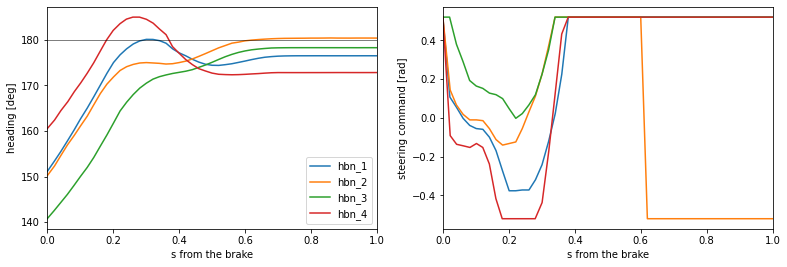

,brake at [deg],braked at [deg],widest [deg],stop [deg],most countersteer while turning
run,,,,,
hbn_1,150,151.13,180.10,176.51,-0.38
hbn_2,150,150.19,180.40,180.35,-0.14
hbn_3,140,140.79,178.28,178.27,-0.00
hbn_4,160,160.52,184.98,172.83,-0.52


In [9]:
CAR = {'hbn_1': 150, 'hbn_2': 150, 'hbn_3': 140, 'hbn_4': 160}
rows = []
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for i, (run, brake_at) in enumerate(CAR.items()):
    s = pd.read_parquet(f'{B}/{run}_parquet/handbrake_state.parquet')
    sl = s[s['phase'] == 4]
    t = sl['t'] - sl['t'].iloc[0]
    ax[0].plot(t, np.degrees(sl['heading']), f'C{i}', label=run)
    ax[1].plot(t, sl['steer'], f'C{i}', label=run)
    rows.append({'run': run, 'brake at [deg]': brake_at, 'braked at [deg]': np.degrees(sl['heading'].iloc[0]),
                 'widest [deg]': np.degrees(sl['heading'].max()), 'stop [deg]': np.degrees(sl['heading'].iloc[-1]),
                 'most countersteer while turning': sl.loc[sl['r'] > 0.5, 'steer'].min()})
ax[0].axhline(180, color='k', lw=0.5)
ax[0].set(xlabel='s from the brake', ylabel='heading [deg]', xlim=(0, 1))
ax[1].set(xlabel='s from the brake', ylabel='steering command [rad]', xlim=(0, 1))
ax[0].legend()
plt.show()
pd.DataFrame(rows).set_index('run').round(2)

### Result

Braked within 1 deg of `brake_at`, stopped at 176.5, 180.3, 178.3 and 172.8 deg, against 177-198
open loop. In `hbn_1` and `hbn_4` the node countersteered while the car still turned (-0.38 and -0.52):
the car stopped turning at the wheel lock and swung back, 180.1 to 174.6 and 185.0 to 172.4 deg, as
in `hb_cs`. In all four the node ended at full lock after the wheel lock, pulling the car on by up to 6 deg
(`hbn_2`: 174.7 to 180.3).

So the node now keeps the steering between full lock and -0.15 (the most `hbn_2` used while turning,
no swing back), takes the rear x1.5 and brakes at 145 deg by default: 35 deg to go, between the
wheels straight and full lock.

## Gazebo

The node now: countersteer to -0.15, the rear x1.5, brake at 145 deg by default. The simulated car
with the rear x1.5 (sim_car `tire` parameter), and x1.2 and x1.8 against the node's 1.5.

In [10]:
SIM = {'sim_hb7': (1.5, 145), 'sim_hb8': (1.5, 140), 'sim_hb9': (1.2, 145), 'sim_hb10': (1.8, 145)}
rows = []
for run, (rear, brake_at) in SIM.items():
    s = pd.read_parquet(f'{B}/{run}_parquet/handbrake_state.parquet')
    g = pd.read_parquet(f'{B}/{run}_parquet/ground_truth.parquet')
    x0, y0, yaw0 = g[['x', 'y', 'yaw']].iloc[5]
    dx, dy = g['x'].iloc[-1] - x0, g['y'].iloc[-1] - y0
    sl = s[s['phase'] == 4]
    rows.append({'run': run, 'rear of the car': rear, 'brake at [deg]': brake_at,
                 'braked at [deg]': np.degrees(sl['heading'].iloc[0]), 'stop, gyro [deg]': np.degrees(sl['heading'].iloc[-1]),
                 'stop, true [deg]': np.degrees(np.angle(np.exp(1j * (g['yaw'].iloc[-1] - yaw0)))) % 360,
                 'stop x [m]': dx * np.cos(yaw0) + dy * np.sin(yaw0), 'stop y [m]': -dx * np.sin(yaw0) + dy * np.cos(yaw0)})
pd.DataFrame(rows).set_index('run').round(2)

,rear of the car,brake at [deg],braked at [deg],"stop, gyro [deg]","stop, true [deg]",stop x [m],stop y [m]
run,,,,,,,
sim_hb7,1.5,145,145.34,181.07,181.57,1.55,1.47
sim_hb8,1.5,140,141.57,181.51,182.05,1.58,1.46
sim_hb9,1.2,145,146.26,189.32,190.69,1.49,1.25
sim_hb10,1.8,145,147.36,178.96,181.00,1.55,1.67


### Result

From 145 and 140 deg the node stops at 181.1 and 181.5 deg (gyro; 181.6 and 182.1 true), with the
car's rear at x1.8 at 179.0. At x1.2 it turns past, 189.3 deg: held to -0.15 the node cannot stop a
car that slides with less friction than it expects, the price of not countersteering. The stop
position moves with the brake point and the friction, 1.49-1.58 m ahead and 1.25-1.67 m left of the
start: nothing controls it yet.